In [2]:
import warnings
warnings.filterwarnings("ignore")

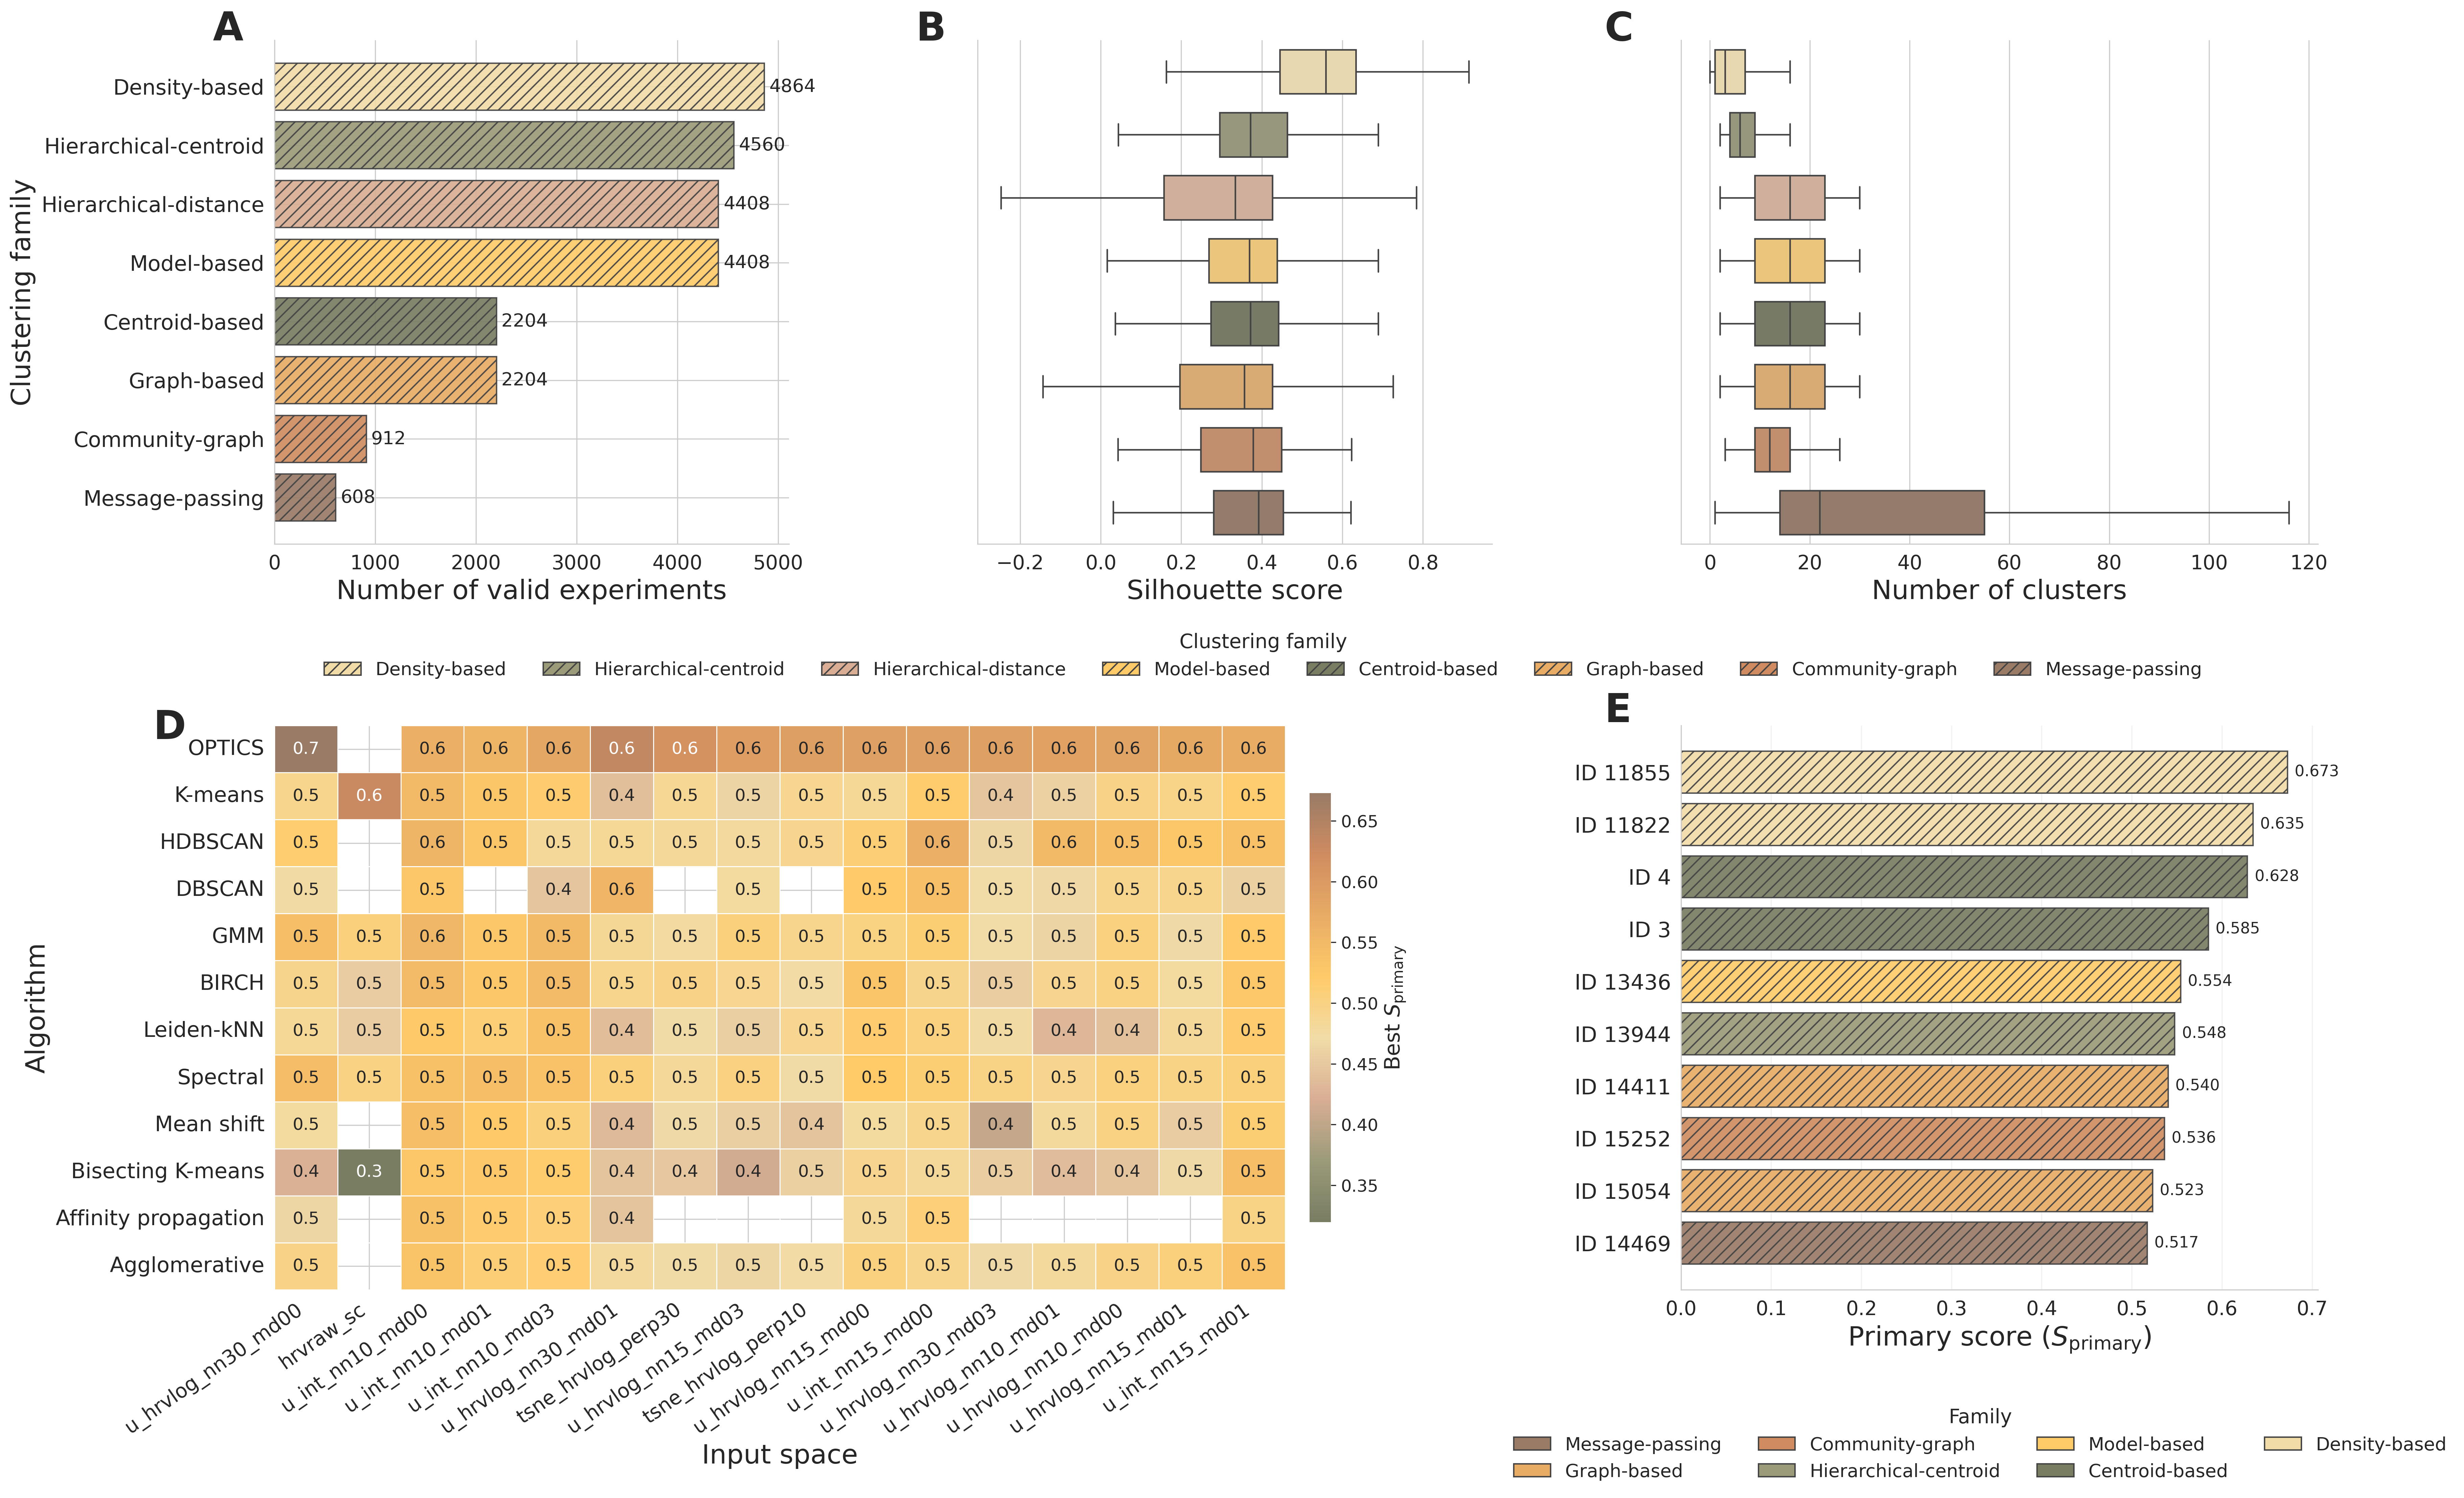

Saved PNG: /home/dmedina/Desktop/colabs/HRV_analysis/results/clustering_exploration_summary_figure/figure_clustering_exploration_summary_5panels_final_v2.png
Saved PDF: /home/dmedina/Desktop/colabs/HRV_analysis/results/clustering_exploration_summary_figure/figure_clustering_exploration_summary_5panels_final_v2.pdf


In [24]:
# ============================================================
# Figure X. Clustering exploration benchmark summary
# Final refined 5-panel version
# A) valid experiments by family (horizontal)
# B) silhouette by family (horizontal)
# C) number of clusters by family (horizontal)
# D) best S_primary by algorithm × space (annotated)
# E) top-10 clustering strategies ranked by primary score
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
BASE_DIR = Path("../../results/").resolve()

RESULTS_FILE = BASE_DIR / "clustering_exploration" / "tables" / "clustering_exploration_results.csv"
ALL_SCORED_FILE = BASE_DIR / "selection_method_outputs" / "all_scored_partitions.csv"
TOPK_FILE = BASE_DIR / "selection_method_outputs" / "topk_selected_partitions.csv"

OUT_DIR = BASE_DIR / "clustering_exploration_summary_figure"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Global style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 19,
    "xtick.labelsize": 14,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
    "figure.dpi": 300,
})

sns.set_style("whitegrid")

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------
def add_panel_letter(ax, letter, x=-0.12, y=1.06):
    ax.text(
        x, y, letter,
        transform=ax.transAxes,
        fontsize=28,
        fontweight="bold",
        va="top",
        ha="left"
    )

def pretty_family_name(x: str) -> str:
    x = str(x).replace("_", "-")
    mapping = {
        "centroid-based": "Centroid-based",
        "hierarchical-centroid": "Hierarchical-centroid",
        "hierarchical-distance": "Hierarchical-distance",
        "density-based": "Density-based",
        "model-based": "Model-based",
        "graph-based": "Graph-based",
        "community-graph": "Community-graph",
        "message-passing": "Message-passing",
    }
    return mapping.get(x, x.replace("-", " ").title().replace(" ", "-"))

def pretty_algorithm_name(x: str) -> str:
    x = str(x)
    mapping = {
        "kmeans": "K-means",
        "bisecting_kmeans": "Bisecting K-means",
        "gmm": "GMM",
        "dbscan": "DBSCAN",
        "hdbscan": "HDBSCAN",
        "optics": "OPTICS",
        "birch": "BIRCH",
        "spectral": "Spectral",
        "agglomerative": "Agglomerative",
        "affinity_propagation": "Affinity propagation",
        "meanshift": "Mean shift",
        "leiden_knn": "Leiden-kNN",
    }
    return mapping.get(x, x.replace("_", " ").title())

def shorten_space_name(x: str) -> str:
    x = str(x)
    replacements = {
        "umap_": "u_",
        "integrated": "int",
        "scaled": "sc",
        "raw": "raw",
        "hrv_log": "hrvlog",
        "hrv_raw": "hrvraw",
        "demographic": "demo",
        "descriptor": "desc",
        "physiological": "phys",
        "clinical": "clin",
    }
    for k, v in replacements.items():
        x = x.replace(k, v)
    return x

# ------------------------------------------------------------
# 4. Load data
# ------------------------------------------------------------
exploration_results = pd.read_csv(RESULTS_FILE)
all_scored = pd.read_csv(ALL_SCORED_FILE)
topk_df = pd.read_csv(TOPK_FILE)

# ------------------------------------------------------------
# 5. Preprocess
# ------------------------------------------------------------
valid_df = exploration_results.loc[exploration_results["status"] == "ok"].copy()
valid_df = valid_df.dropna(subset=["family", "algorithm", "space_name"])

if "S_primary" not in all_scored.columns:
    raise ValueError("Column 'S_primary' was not found in all_scored_partitions.csv")

if "S_primary" not in topk_df.columns:
    raise ValueError("Column 'S_primary' was not found in topk_selected_partitions.csv")

family_order = (
    valid_df["family"]
    .value_counts()
    .sort_values(ascending=False)
    .index
    .tolist()
)

family_palette = {
    "centroid-based": "#797d62",
    "hierarchical-centroid": "#9b9b7a",
    "hierarchical-distance": "#d9ae94",
    "density-based": "#f1dca7",
    "model-based": "#ffcb69",
    "graph-based": "#e8ac65",
    "community-graph": "#d08c60",
    "message-passing": "#997b66",
}

heat_colors = list(family_palette.values())

heat_cmap = LinearSegmentedColormap.from_list(
    "family_gradient",
    heat_colors,
    N=256
)

default_color = "#7f7f7f"

pretty_family_labels = {f: pretty_family_name(f) for f in family_order}

# ---------- Top-k ranking ----------
topk_plot = topk_df.sort_values("S_primary", ascending=True).copy()
topk_plot["rank_label"] = "ID " + topk_plot["experiment_id"].astype(int).astype(str)
topk_plot["family_color"] = topk_plot["family"].map(family_palette).fillna(default_color)

# ---------- Heatmap ----------
heatmap_df = all_scored.dropna(subset=["algorithm", "space_name", "S_primary"]).copy()

pivot_primary = heatmap_df.pivot_table(
    index="algorithm",
    columns="space_name",
    values="S_primary",
    aggfunc="max"
)

row_order = pivot_primary.max(axis=1).sort_values(ascending=False).index.tolist()

top_spaces_from_topk = topk_df["space_name"].drop_duplicates().tolist()
remaining_space_ranking = (
    pivot_primary.max(axis=0)
    .sort_values(ascending=False)
    .index
    .tolist()
)

selected_spaces = []
for s in top_spaces_from_topk + remaining_space_ranking:
    if s not in selected_spaces:
        selected_spaces.append(s)

selected_spaces = selected_spaces[:16]
pivot_primary = pivot_primary.loc[row_order, selected_spaces]

pivot_primary.index = [pretty_algorithm_name(i) for i in pivot_primary.index]
pivot_primary.columns = [shorten_space_name(c) for c in pivot_primary.columns]

# ------------------------------------------------------------
# 6. Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(26, 16))
gs = fig.add_gridspec(
    nrows=2, ncols=3,
    width_ratios=[1.05, 1.05, 1.30],
    height_ratios=[1.0, 1.12],
    wspace=0.34,
    hspace=0.34
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])
axD = fig.add_subplot(gs[1, 0:2])
axE = fig.add_subplot(gs[1, 2])

# ------------------------------------------------------------
# 7. Panel A — valid experiments by family
# ------------------------------------------------------------
family_counts = (
    valid_df["family"]
    .value_counts()
    .reindex(family_order)
)

ypos = np.arange(len(family_order))
bars = axA.barh(
    ypos,
    family_counts.values,
    color=[family_palette.get(f, default_color) for f in family_order],
    edgecolor="#444444",
    linewidth=1.0,
    hatch="///",
    alpha=0.92
)

axA.set_yticks(ypos)
axA.set_yticklabels([pretty_family_labels[f] for f in family_order])
axA.invert_yaxis()
axA.set_xlabel("Number of valid experiments")
axA.set_ylabel("Clustering family")

for b in bars:
    axA.text(
        b.get_width() + max(family_counts.values) * 0.010,
        b.get_y() + b.get_height() / 2,
        f"{int(b.get_width())}",
        va="center",
        ha="left",
        fontsize=13
    )

add_panel_letter(axA, "A")

# ------------------------------------------------------------
# 8. Panel B — silhouette by family
# ------------------------------------------------------------
sns.boxplot(
    data=valid_df,
    y="family",
    x="silhouette",
    order=family_order,
    palette=[family_palette.get(f, default_color) for f in family_order],
    ax=axB,
    width=0.70,
    showfliers=False,
    linewidth=1.1
)

axB.set_xlabel("Silhouette score")
axB.set_ylabel("")
axB.set_yticklabels([pretty_family_labels[f] for f in family_order])
add_panel_letter(axB, "B")

# ------------------------------------------------------------
# 9. Panel C — number of clusters by family
# ------------------------------------------------------------
sns.boxplot(
    data=valid_df,
    y="family",
    x="n_clusters",
    order=family_order,
    palette=[family_palette.get(f, default_color) for f in family_order],
    ax=axC,
    width=0.70,
    showfliers=False,
    linewidth=1.1
)

axC.set_xlabel("Number of clusters")
axC.set_ylabel("")
axC.set_yticklabels([pretty_family_labels[f] for f in family_order])
add_panel_letter(axC, "C")

# keep only one family label column
axB.set_yticklabels([])
axC.set_yticklabels([])
axB.tick_params(axis="y", left=False)
axC.tick_params(axis="y", left=False)

# ------------------------------------------------------------
# 10. Shared family legend BELOW A–C (still in first row)
# ------------------------------------------------------------
legend_handles_families = [
    Patch(
        facecolor=family_palette.get(f, default_color),
        edgecolor="#444444",
        hatch="///",
        label=pretty_family_labels[f]
    )
    for f in family_order
]

fig.legend(
    handles=legend_handles_families,
    title="Clustering family",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.525),
    ncol=8,
    frameon=False
)

# ------------------------------------------------------------
# 11. Panel D — heatmap annotated
# ------------------------------------------------------------
hm = sns.heatmap(
    pivot_primary,
    cmap=heat_cmap,
    linewidths=0.65,
    linecolor="white",
    cbar=True,
    ax=axD,
    annot=True,
    fmt=".1f",
    annot_kws={"fontsize": 12},
    cbar_kws={
        "label": r"Best $S_{\mathrm{primary}}$",
        "shrink": 0.76,
        "pad": 0.02
    }
)

axD.set_xlabel("Input space")
axD.set_ylabel("Algorithm")
axD.set_xticklabels(axD.get_xticklabels(), rotation=35, ha="right")
axD.set_yticklabels(axD.get_yticklabels(), rotation=0)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r"Best $S_{\mathrm{primary}}$", fontsize=15)

# moved further left
add_panel_letter(axD, "D", x=-0.12, y=1.03)

# ------------------------------------------------------------
# 12. Panel E — top-10 ranking
# ------------------------------------------------------------
bars = axE.barh(
    topk_plot["rank_label"],
    topk_plot["S_primary"],
    color=topk_plot["family_color"],
    edgecolor="#444444",
    linewidth=1.0,
    hatch="///",
    alpha=0.92
)

axE.set_xlabel(r"Primary score ($S_{\mathrm{primary}}$)")
axE.set_ylabel("")
axE.grid(axis="x", alpha=0.25)
axE.grid(axis="y", visible=False)

for b, score in zip(bars, topk_plot["S_primary"]):
    axE.text(
        b.get_width() + 0.008,
        b.get_y() + b.get_height() / 2,
        f"{score:.3f}",
        va="center",
        ha="left",
        fontsize=11
    )

legend_families_topk = topk_plot["family"].drop_duplicates().tolist()
legend_handles_topk = [
    Patch(
        facecolor=family_palette.get(f, default_color),
        edgecolor="#444444",
        label=pretty_family_name(f)
    )
    for f in legend_families_topk
]

axE.legend(
    handles=legend_handles_topk,
    title="Family",
    loc="upper center",
    bbox_to_anchor=(0.47, -0.18),
    ncol=4,
    frameon=False
)

add_panel_letter(axE, "E")

# ------------------------------------------------------------
# 13. Cosmetics
# ------------------------------------------------------------
for ax in [axA, axB, axC, axD, axE]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 14. Save
# ------------------------------------------------------------
png_path = OUT_DIR / "figure_clustering_exploration_summary_5panels_final_v2.png"
pdf_path = OUT_DIR / "figure_clustering_exploration_summary_5panels_final_v2.pdf"

plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.98])
plt.savefig(png_path, dpi=400, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")